# Question 1 

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import ecdf
import numpy as np
from scipy.stats import norm, lognorm, kstest, expon
import sys

In [6]:
def empCDF_plot(dataArray):
    emp_cdf = ecdf(dataArray)

    plt.figure(figsize=(6, 4))
    ax = plt.subplot()
    emp_cdf.cdf.plot(ax)
    plt.xlabel("Value")
    plt.ylabel("CDF")
    plt.show()


Empirical CDF


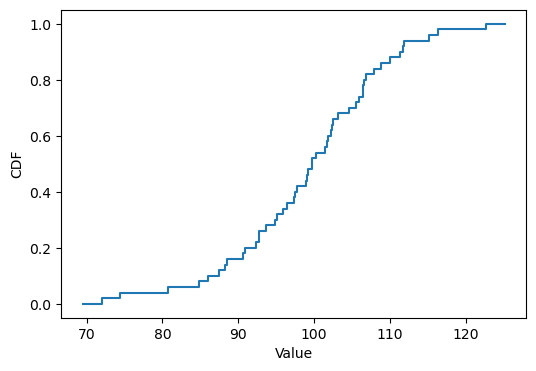


Sample Space
Minimum Travel Time: 72.0
Maximum Travel Time: 122.7

Parameter Estimation
Normal fit:
mu_hat = 99.222
sigma_hat = 10.066981474106328
sigma_hat_squared = 101.34411600000001

Log-normal fit:
mu_L_hat = 4.591970931362713
sigma_L_hat = 0.10519277318438083

Goodness of Fit (KS-test)
Normal fit:
---------------------
D       = 0.0682
p-value = 0.9619
Decision: FAIL TO REJECT H0 - data is consistent with Normal

Log-normal fit:
---------------------
D       = 0.0903
p-value = 0.7761
Decision: FAIL TO REJECT H0 - data is consistent with Log-Normal

Decision fit:
---------------------
KS-statistic (D): Normal D=0.0682 < Log-Normal D=0.0903 --> Normal is the better fit (lower D)
p-value:          Normal p=0.9619 > Log-Normal p=0.7761 --> Normal is the better fit (higher p)


In [9]:
Z = np.array([92.3, 92.8, 106.8, 108.9, 106.6, 115.2, 94.8, 106.4, 110.0, 90.9, 
     104.6, 72.0, 86.0, 102.4, 99.8, 87.5, 111.4, 105.9, 90.7, 99.2, 
     97.8, 88.3, 97.5, 97.4, 93.7, 99.7, 122.7, 100.2, 106.5, 105.5, 
     80.7, 107.9, 103.2, 116.4, 101.7, 84.8, 101.9, 99.1, 102.2, 102.5, 
     111.7, 101.5, 95.1, 92.8, 88.5, 74.4, 98.9, 111.9, 96.5, 95.9])

# Step 1: ECDF
# -------------------------
print("\nEmpirical CDF")
print("=" * 30)
empCDF_plot(Z)


# Step 2: Sample Space
# -------------------------
print("\nSample Space")
print("=" * 30)
print('Minimum Travel Time:', min(Z))
print('Maximum Travel Time:', max(Z))


# Step 4: estimate parameters MLE
# -------------------------
# Normal: X ~ N(mu, sigma^2)
# https://en.wikipedia.org/wiki/Normal_distribution#Definitions
mu_hat, sigma_hat = norm.fit(Z)

# Log-normal: X ~ Lognormal(mu_L, sigma_L^2)
# https://en.wikipedia.org/wiki/Log-normal_distribution#Definitions
shape_ln, loc_ln, scale_ln = lognorm.fit(Z, floc=0) # forces location = 0 (standard lognormal model)
sigma_L_hat = shape_ln
mu_L_hat = np.log(scale_ln)

# print
print("\nParameter Estimation")
print("=" * 30)
print("Normal fit:")
print("mu_hat =", mu_hat)
print("sigma_hat =", sigma_hat)
print("sigma_hat_squared =", sigma_hat*sigma_hat)

print("\nLog-normal fit:")
print("mu_L_hat =", mu_L_hat)
print("sigma_L_hat =", sigma_L_hat)


# Step 5: goodness of fit
# -------------------------

print("\nGoodness of Fit (KS-test)")
print("=" * 30)
# Normal KS test
ks_normal = stats.kstest(Z, 'norm', args=(mu_hat, sigma_hat))

# Lognormal KS test
ks_lognormal = stats.kstest(Z, 'lognorm', args=(shape_ln, loc_ln, scale_ln))

print("Normal fit:")
print("-" * 21)
print(f"D       = {ks_normal.statistic:.4f}")
print(f"p-value = {ks_normal.pvalue:.4f}")
print("Decision:", "REJECT H0 - data does not follow Normal" if ks_normal.pvalue < 0.05 
      else "FAIL TO REJECT H0 - data is consistent with Normal")

print("\nLog-normal fit:")
print("-" * 21)
print(f"D       = {ks_lognormal.statistic:.4f}")
print(f"p-value = {ks_lognormal.pvalue:.4f}")
print("Decision:", "REJECT H0 - data does not follow Log-Normal" if ks_lognormal.pvalue < 0.05 
      else "FAIL TO REJECT H0 - data is consistent with Log-Normal")

print("\nDecision fit:")
print("-" * 21)
print(f"KS-statistic (D): Normal D={ks_normal.statistic:.4f} {'<' if ks_normal.statistic < ks_lognormal.statistic else '>'} Log-Normal D={ks_lognormal.statistic:.4f} "
      f"--> {'Normal' if ks_normal.statistic < ks_lognormal.statistic else 'Log-Normal'} is the better fit (lower D)")
print(f"p-value:          Normal p={ks_normal.pvalue:.4f} {'>' if ks_normal.statistic < ks_lognormal.statistic else '<'} Log-Normal p={ks_lognormal.pvalue:.4f} "
      f"--> {'Normal' if ks_normal.pvalue > ks_lognormal.pvalue else 'Log-Normal'} is the better fit (higher p)")



# Question 2

# Question 3

In [30]:
import numpy as np
from scipy import stats
from scipy.stats import norm, expon
from scipy.stats import chisquare

interarrival_times = np.array([
    1.9, 5.3, 1.1, 4.7, 17.8, 44.3, 9.0, 18.9, 114.2, 47.3, 
    47.1, 11.2, 60.1, 38.6, 107.6, 56.4, 10.0, 31.4, 58.6, 
    5.5, 11.8, 62.4, 24.3, 0.9, 44.5, 115.8, 2.0, 50.3, 21.1, 2.6
])

service_times = np.array([
    8.9, 13.6, 21.6, 20.8, 19.9, 20.6, 21.0, 27.7, 10.0, 27.7, 
    13.1, 25.5, 22.7, 33.9, 14.5, 29.0, 9.9, 26.8, 18.7, 17.3, 
    14.1, 29.0, 14.2, 24.3, 31.2, 25.3, 27.3, 23.4, 18.4, 20.0
])


### KS-Test

In [31]:
# ---------------------------------------
# KS-test
# ---------------------------------------
print("=" * 90)
print("Goodness of Fit (KS-test)")
print("=" * 90)

# ---- Normal ----
# interarrival_times
mu_int, sigma_int = norm.fit(interarrival_times)
ks_normal_int = stats.kstest(interarrival_times, 'norm', args=(mu_int, sigma_int))

# service_times
mu_ser, sigma_ser = norm.fit(service_times)
ks_normal_ser = stats.kstest(service_times, 'norm', args=(mu_ser, sigma_ser))


# ---- Exponential ----
# interarrival_times
loc_exp_int, scale_exp_int = expon.fit(interarrival_times, floc=0)
ks_exp_int = stats.kstest(interarrival_times, 'expon', args=(loc_exp_int, scale_exp_int))

# service_times
loc_exp_ser, scale_exp_ser = expon.fit(service_times, floc=0)
ks_exp_ser = stats.kstest(service_times, 'expon', args=(loc_exp_ser, scale_exp_ser))

results = {
    "Normal (interarrival times)":      ks_normal_int,
    "Exponential (interarrival times)": ks_exp_int,
    "Normal (service times)":           ks_normal_ser,
    "Exponential (service times)":      ks_exp_ser
}

print(f"{'Distribution':<31} {'D':>8} {'p-value':>17}  {'Decision':>11}")
print("-" * 75)
for name, res in results.items():
    decision = "REJECT H0" if res.pvalue < 0.05 else "FAIL TO REJECT H0"
    print(f"{name:<38} D = {res.statistic:.4f}  p = {res.pvalue:.4f}  {decision:<18}")
    

Goodness of Fit (KS-test)
Distribution                           D           p-value     Decision
---------------------------------------------------------------------------
Normal (interarrival times)            D = 0.1563  p = 0.4138  FAIL TO REJECT H0 
Exponential (interarrival times)       D = 0.1259  p = 0.6816  FAIL TO REJECT H0 
Normal (service times)                 D = 0.1062  p = 0.8527  FAIL TO REJECT H0 
Exponential (service times)            D = 0.3639  p = 0.0005  REJECT H0         


### Simulation

In [ ]:
# https://www.schoolofsimulation.com/blog_posts/simpy-queue-model

## Current System

In [146]:
import simpy
import random
import statistics
import math

# ── Parameters ────────────────────────────────────────────────────────────────
ARRIVAL_RATE  = 1 / np.mean(interarrival_times)    # Poisson arrivals
MU_SERVICE    = np.mean(service_times)             # Stage 1 Normal service mean (min)
SIGMA_SERVICE = np.std(service_times)              # Stage 1 Normal service std  (min)
P_FAIL_S1     = 0.20        # 20% fail initial review → routed to Stage 2
P_FAIL_S2     = 0.50        # 50% fail second review (tracked, both leave)
U_LOW         = 25          # Stage 2 Uniform lower bound (min)
U_HIGH        = 35          # Stage 2 Uniform upper bound (min)

SIM_TIME      = 1000     # (minutes)
REPLICATIONS  = 20


# ── Current System Class ──────────────────────────────────────────────────────
class CurrentSystem:
    """
    Stage 1: M/G/2 → Stage 2: M/G/1

    Stage 1 (M/G/2): 2 agents, Normal(21.01, 6.68²) service
    Stage 2 (M/G/1): 1 agent, Uniform(25,35) service
    """

    def __init__(self, env):
        self.env    = env
        # simpy.Resource = Number of Servers ← same as Multiple Servers
        self.stage1 = simpy.Resource(env, capacity=2)  # M/G/2: 2 parallel servers
        self.stage2 = simpy.Resource(env, capacity=1)  # M/G/1: 1 server

        # Collecting Statistics  ← same as QueueStats
        self.wait_times_s1    = []
        self.wait_times_s2    = []
        self.service_times_s1 = []
        self.service_times_s2 = []
        self.queue_log        = []

        # Counters
        self.n_arrived     = 0
        self.n_approved_s1 = 0
        self.n_to_s2       = 0
        self.n_approved_s2 = 0
        self.n_rejected_s2 = 0

    # ── Customer process ──────────────────────────────────────────────────────
    def customer(self, name):
        arrival = self.env.now
        self.n_arrived += 1

        # ── Stage 1: Initial Review  (M/G/2: G = Normal) ───────────────
        with self.stage1.request() as req:
            yield req
            wait1 = self.env.now - arrival
            self.wait_times_s1.append(wait1)

            s1 = max(random.gauss(MU_SERVICE, SIGMA_SERVICE), 1.0)  # floor at 1
            self.service_times_s1.append(s1)
            yield self.env.timeout(s1)

        # EXIT: 80% approved
        if random.random() >= P_FAIL_S1:
            self.n_approved_s1 += 1
            return # exit when return call

        self.n_to_s2 += 1

        # ── Stage 2: Second Review  (M/G/1: G = Uniform(25,35)) ────────
        s2_arrive = self.env.now
        with self.stage2.request() as req:
            yield req
            wait2 = self.env.now - s2_arrive
            self.wait_times_s2.append(wait2)

            s2 = random.uniform(U_LOW, U_HIGH)
            self.service_times_s2.append(s2)
            yield self.env.timeout(s2)

        # EXIT: 50% approved, 50% rejected — both leave system
        if random.random() >= P_FAIL_S2:
            self.n_approved_s2 += 1
        else:
            self.n_rejected_s2 += 1

    # ── Arrival process ───────── ← same as Arrival
    def arrivals(self):
        i = 0
        while True:
            yield self.env.timeout(random.expovariate(ARRIVAL_RATE))
            self.env.process(self.customer(f"App-{i}"))
            i += 1

    # ── Queue monitor ──────────── ← same as Monitor
    def monitor(self, interval=10):
        while True:
            self.queue_log.append({
                'time'     : self.env.now,
                'q_stage1' : len(self.stage1.queue),
                'q_stage2' : len(self.stage2.queue),
                'busy_s1'  : self.stage1.count,
                'busy_s2'  : self.stage2.count,
            })
            yield self.env.timeout(interval)

    # ── Run ───────────────────────────────────────────────────────────────────
    def run(self, until):
        self.env.process(self.arrivals())
        self.env.process(self.monitor())
        self.env.run(until=until)

    # ── Report  ──────────────────── ← same pattern as Report
    def report(self):
        def avg(lst):   return statistics.mean(lst) if lst else 0.0
        def pct90(lst): return sorted(lst)[int(0.9 * len(lst))] if lst else 0.0
        def pct95(lst): return sorted(lst)[int(0.95 * len(lst))] if lst else 0.0

        # ── Throughput ────────────────────────────────────────────────────────
        n_completed   = self.n_approved_s1 + self.n_approved_s2 + self.n_rejected_s2
        n_succeeded   = self.n_approved_s1 + self.n_approved_s2
        n_failed      = self.n_rejected_s2
        throughput    = n_completed / SIM_TIME   # completed applications per min
        pct_success   = 100 * n_succeeded / n_completed if n_completed else 0
        pct_fail      = 100 * n_failed    / n_completed if n_completed else 0

        # ── Wait & Service ────────────────────────────────────────────────────
        avg_wait_s1   = avg(self.wait_times_s1)
        avg_wait_s2   = avg(self.wait_times_s2)
        avg_total_wait = avg([w1 + w2
                              for w1, w2 in zip(self.wait_times_s1,
                                                self.wait_times_s2[:len(self.wait_times_s1)])]
                             ) if self.wait_times_s1 else 0.0
        avg_total_wait = avg_wait_s1 + P_FAIL_S1 * avg_wait_s2

        avg_svc_s1    = avg(self.service_times_s1)
        avg_svc_s2    = avg(self.service_times_s2)
        max_wait_s1   = max(self.wait_times_s1)   if self.wait_times_s1 else 0.0
        max_wait_s2   = max(self.wait_times_s2)   if self.wait_times_s2 else 0.0

        # ── Utilization ───────────────────────────────────────────────────────
        util_s1 = sum(self.service_times_s1) / (SIM_TIME * 2)  # capacity=2
        util_s2 = sum(self.service_times_s2) / (SIM_TIME * 1)  # capacity=1

        # ── Print ─────────────────────────────────────────────────────────────
        W = 52
        def row(label, value): print(f"  {label:<40} {value:>10}")
        def divider():         print(f"  {'-'*W}")
        def header(title):
            print(f"\n  {'─'*W}")
            print(f"  {title}")
            print(f"  {'─'*W}")

        header("THROUGHPUT")
        row("Applications arrived",          f"{self.n_arrived}")
        row("Applications completed",        f"{n_completed}")
        row("Throughput [apps/min]",         f"{throughput:.4f}")
        divider()
        row("Total number approved",         f"{n_succeeded}  ({pct_success:.1f}%)")
        row("  Approved at Stage 1",         f"{self.n_approved_s1}")
        row("  Approved at Stage 2",         f"{self.n_approved_s2}")
        row("Routed to Stage 2",             f"{self.n_to_s2}")
        row("Rejected (at Stage 2)",         f"{n_failed}  ({pct_fail:.1f}%)")

        header("SERVICE TIMES")
        row("Avg service time — Stage 1 [min]",  f"{avg_svc_s1:.3f}")
        row("Avg service time — Stage 2 [min]",  f"{avg_svc_s2:.3f}")
        row("Avg combined time - Stage 1 and 2", f"{avg_svc_s1 + avg_svc_s2:.3f}")

        header("QUEUE WAIT TIMES")
        row("Avg wait — Stage 1 [min]",      f"{avg_wait_s1:.3f}")
        row("Max wait — Stage 1 [min]",      f"{max_wait_s1:.3f}")
        row("90th pct wait — Stage 1 [min]", f"{pct90(self.wait_times_s1):.3f}")
        divider()
        row("Avg wait — Stage 2 [min]",      f"{avg_wait_s2:.3f}")
        row("Max wait — Stage 2 [min]",      f"{max_wait_s2:.3f}")
        row("90th pct wait — Stage 2 [min]", f"{pct90(self.wait_times_s2):.3f}")
        # row("90th pct wait — Stage 2 [min]", f"{sorted(self.wait_times_s2)[int(0.9*len(self.wait_times_s2))]:.2f}")
        divider()
        row("Avg total wait (all stages) [min]", f"{avg_total_wait:.3f}")

        header("UTILIZATION")
        row("Stage 1 utilization (per agent)", f"{util_s1:.3f}  ({util_s1*100:.1f}%)")
        row("Stage 2 utilization",             f"{util_s2:.3f}  ({util_s2*100:.1f}%)")
        print(f"  {'─'*W}\n")


# ── Multiple Replications ─────────────────────────────────────────────────────
def ci95(data):
    n  = len(data)
    se = statistics.stdev(data) / math.sqrt(n)
    return 2.093 * se   # t_{0.025, 19 df}

def run_replications():
    print("=" * 60)
    print("  CURRENT SYSTEM  —  M/G/2 (Stage 1) → M/G/1 (Stage 2)")
    print(f"  {REPLICATIONS} replications × {SIM_TIME:,} min each")
    print("=" * 60)

    keys = ["wait_s1", "wait_s2", "util_s1", "util_s2"]
    results = {k: [] for k in keys}

    print(f"\n{'Rep':>4}  {'E[Wait_S1]':>12}  {'E[Wait_S2]':>12}  "
          f"{'ρ_S1: S1 utilization':>21}  {'ρ_S2: S2 utilization':>21}")
    print("-" * 79)

    for r in range(REPLICATIONS):
        random.seed(42 + r)
        env    = simpy.Environment()
        system = CurrentSystem(env)
        system.run(until=SIM_TIME)

        def avg(lst): return statistics.mean(lst) if lst else 0.0

        ew1   = avg(system.wait_times_s1)
        ew2   = avg(system.wait_times_s2)
        rho1  = sum(system.service_times_s1) / (SIM_TIME * 2)
        rho2  = sum(system.service_times_s2) / (SIM_TIME * 1)

        results["wait_s1"].append(ew1)
        results["wait_s2"].append(ew2)
        results["util_s1"].append(rho1)
        results["util_s2"].append(rho2)

        print(f"{r+1:>4}  {ew1:>12.3f}  {ew2:>12.3f}  {rho1:>21.3f}  {rho2:>21.3f}")

    print("-" * 79)
    print("\n  CROSS-REPLICATION SUMMARY  (mean ± 95% CI)\n")
    labels = {
        "wait_s1" : "Avg queue wait — Stage 1 [min]",
        "wait_s2" : "Avg queue wait — Stage 2 [min]",
        "util_s1" : "Stage 1 utilisation (per agent)",
        "util_s2" : "Stage 2 utilisation",
    }
    for k, label in labels.items():
        mu = statistics.mean(results[k])
        hw = ci95(results[k])
        print(f"  {label:<36}  {mu:.4f}  ±  {hw:.4f}")

    # Detailed report for last replication
    print("\n" + "=" * 60)
    print("  DETAILED REPORT — Final Replication")
    print("=" * 60)
    system.report()
    print()


# ── Entry Point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    run_replications()

  CURRENT SYSTEM  —  M/G/2 (Stage 1) → M/G/1 (Stage 2)
  20 replications × 1,000 min each

 Rep    E[Wait_S1]    E[Wait_S2]   ρ_S1: S1 utilization   ρ_S2: S2 utilization
-------------------------------------------------------------------------------
   1         1.245         2.979                  0.336                  0.110
   2         0.000         0.000                  0.317                  0.122
   3         0.787         3.826                  0.380                  0.338
   4         1.565         4.641                  0.281                  0.170
   5         0.062         0.000                  0.271                  0.143
   6         2.051         0.000                  0.375                  0.160
   7         2.618         5.309                  0.398                  0.185
   8         0.514         0.000                  0.329                  0.135
   9         0.097         0.000                  0.253                  0.207
  10         1.318         0.000       

In [148]:
import simpy
import random
import statistics
import math

# ── Parameters ────────────────────────────────────────────────────────────────
ARRIVAL_RATE  = 1 / np.mean(interarrival_times)    # Poisson arrivals
MU_SERVICE    = np.mean(service_times)             # Stage 1 Normal service mean (min)
SIGMA_SERVICE = np.std(service_times)              # Stage 1 Normal service std  (min)
P_FAIL_S1     = 0.20        # 20% fail initial review → same agent does Stage 2
P_FAIL_S2     = 0.50        # 50% fail second review (tracked, both leave)
U_LOW         = 25          # Stage 2 Uniform lower bound (min)
U_HIGH        = 35          # Stage 2 Uniform upper bound (min)

SIM_TIME      = 1000        # (minutes)
REPLICATIONS  = 20


# ── Proposed System Class ─────────────────────────────────────────────────────
class ProposedSystem:
    """
    Stage 1 + Stage 2: 2 × M/G/1 
    Each Agent (M/G/1): handles both stages (if needed)
    """

    def __init__(self, env):
        self.env = env

        # simpy.Resource = Number of Servers ← same as Multiple Servers
        self.agent1 = simpy.Resource(env, capacity=1)  # M/G/1: agent 1
        self.agent2 = simpy.Resource(env, capacity=1)  # M/G/1: agent 2

        # Collecting Statistics  ← same as QueueStats
        self.wait_times       = []   # queue wait before agent (Stage 1 entry)
        self.service_times_s1 = []   # Stage 1 service times
        self.service_times_s2 = []   # Stage 2 service times (20% subset)
        self.hold_times       = []   # total agent hold = s1 (+ s2 if failed)
        self.queue_log        = []

        # Counters
        self.n_arrived     = 0
        self.n_approved_s1 = 0
        self.n_to_s2       = 0
        self.n_approved_s2 = 0
        self.n_rejected_s2 = 0

    # ── Routing: pick the shorter queue ──────────────────────────────────────
    def _pick_agent(self):
        """Join-the-shortest-queue: route to agent with least total load."""
        load1 = len(self.agent1.queue) + self.agent1.count
        load2 = len(self.agent2.queue) + self.agent2.count
        return self.agent1 if load1 <= load2 else self.agent2

    # ── Customer process ──────────────────────────────────────────────────────
    def customer(self, name):
        arrival = self.env.now
        self.n_arrived += 1

        agent = self._pick_agent() # pick agent with less queue

        with agent.request() as req:
            yield req
            wait = self.env.now - arrival
            self.wait_times.append(wait)

            # ── Stage 1: Initial Review  (M/G/1: G = Normal) ─────────────────
            s1 = max(random.gauss(MU_SERVICE, SIGMA_SERVICE), 1.0)  # floor at 1
            self.service_times_s1.append(s1)
            yield self.env.timeout(s1)

            # EXIT: 80% approved
            if random.random() >= P_FAIL_S1:
                self.n_approved_s1 += 1
                self.hold_times.append(s1) # agent free
            else:
                # ── Stage 2: Second Review  (M/G/1: G = Uniform(25,35)) ──────
                # same agent continues, agent held
                self.n_to_s2 += 1
                s2 = random.uniform(U_LOW, U_HIGH)
                self.service_times_s2.append(s2)
                yield self.env.timeout(s2)

                self.hold_times.append(s1 + s2)

                # EXIT: 50% approved, 50% rejected
                if random.random() >= P_FAIL_S2:
                    self.n_approved_s2 += 1
                else:
                    self.n_rejected_s2 += 1
                # agent free

    # ── Arrival process ───────── ← same as Arrival
    def arrivals(self):
        i = 0
        while True:
            yield self.env.timeout(random.expovariate(ARRIVAL_RATE))
            self.env.process(self.customer(f"App-{i}"))
            i += 1

    # ── Queue monitor ──────────── ← same as Monitor
    def monitor(self, interval=10):
        while True:
            self.queue_log.append({
                'time'    : self.env.now,
                'q_agent1': len(self.agent1.queue),
                'q_agent2': len(self.agent2.queue),
                'busy_a1' : self.agent1.count,
                'busy_a2' : self.agent2.count,
            })
            yield self.env.timeout(interval)

    # ── Run ───────────────────────────────────────────────────────────────────
    def run(self, until):
        self.env.process(self.arrivals())
        self.env.process(self.monitor())
        self.env.run(until=until)

    # ── Report  ──────────────────── ← same pattern as Report
    def report(self):
        def avg(lst):   return statistics.mean(lst) if lst else 0.0
        def pct90(lst): return sorted(lst)[int(0.9  * len(lst))] if lst else 0.0
        def pct95(lst): return sorted(lst)[int(0.95 * len(lst))] if lst else 0.0

        # ── Throughput ─────────────────────────────────────────────────────────
        n_completed = self.n_approved_s1 + self.n_approved_s2 + self.n_rejected_s2
        n_succeeded = self.n_approved_s1 + self.n_approved_s2
        n_failed    = self.n_rejected_s2
        throughput  = n_completed / SIM_TIME   # completed applications per min
        pct_success = 100 * n_succeeded / n_completed if n_completed else 0
        pct_fail    = 100 * n_failed    / n_completed if n_completed else 0

        # ── Wait & Service ────────────────────────────────────────────────────
        avg_wait   = avg(self.wait_times)
        avg_svc_s1 = avg(self.service_times_s1)
        avg_svc_s2 = avg(self.service_times_s2)
        avg_hold   = avg(self.hold_times)
        max_wait   = max(self.wait_times) if self.wait_times else 0.0

        # total wait = queue wait only (Stage 2 has no separate queue)
        avg_total_wait = avg_wait

        # ── Utilization ───────────────────────────────────────────────────────
        util = sum(self.hold_times) / (SIM_TIME * 2)  # spread across 2 agents

        # ── Print ─────────────────────────────────────────────────────────────
        W = 52
        def row(label, value): print(f"  {label:<40} {value:>10}")
        def divider():         print(f"  {'-'*W}")
        def header(title):
            print(f"\n  {'─'*W}")
            print(f"  {title}")
            print(f"  {'─'*W}")

        header("THROUGHPUT")
        row("Applications arrived",          f"{self.n_arrived}")
        row("Applications completed",        f"{n_completed}")
        row("Throughput [apps/min]",         f"{throughput:.4f}")
        divider()
        row("Total number approved",         f"{n_succeeded}  ({pct_success:.1f}%)")
        row("  Approved at Stage 1",         f"{self.n_approved_s1}")
        row("  Approved at Stage 2",         f"{self.n_approved_s2}")
        row("Routed to Stage 2",             f"{self.n_to_s2}")
        row("Rejected (at Stage 2)",         f"{n_failed}  ({pct_fail:.1f}%)")

        header("SERVICE TIMES")
        row("Avg service time — Stage 1 [min]",  f"{avg_svc_s1:.3f}")
        row("Avg service time — Stage 2 [min]",  f"{avg_svc_s2:.3f}")
        row("Avg combined time - Stage 1 and 2", f"{avg_svc_s1 + avg_svc_s2:.3f}")
        row("Avg agent hold time [min]",          f"{avg_hold:.3f}")

        header("QUEUE WAIT TIMES")
        row("Avg wait [min]",                f"{avg_wait:.3f}")
        row("Max wait [min]",                f"{max_wait:.3f}")
        row("90th pct wait [min]",           f"{pct90(self.wait_times):.3f}")
        divider()
        row("Avg total wait (all stages) [min]", f"{avg_total_wait:.3f}")

        header("UTILIZATION")
        row("Agent utilization (per agent)", f"{util:.3f}  ({util*100:.1f}%)")
        print(f"  {'─'*W}\n")


# ── Multiple Replications ─────────────────────────────────────────────────────
def ci95(data):
    n  = len(data)
    se = statistics.stdev(data) / math.sqrt(n)
    return 2.093 * se   # t_{0.025, 19 df}

def run_replications():
    print("=" * 60)
    print("  PROPOSED SYSTEM  —  2 × M/G/1 (Stage 1 + Stage 2 per agent)")
    print(f"  {REPLICATIONS} replications × {SIM_TIME:,} min each")
    print("=" * 60)

    keys = ["wait", "hold", "util"]
    results = {k: [] for k in keys}

    print(f"\n{'Rep':>4}  {'E[Wait Time]':>14}  {'E[Hold Time]':>14}  {'ρ: utilization':>15}")
    print("-" * 54)

    for r in range(REPLICATIONS):
        random.seed(42 + r)
        env    = simpy.Environment()
        system = ProposedSystem(env)
        system.run(until=SIM_TIME)

        def avg(lst): return statistics.mean(lst) if lst else 0.0

        ew   = avg(system.wait_times)
        eh   = avg(system.hold_times)
        util = sum(system.hold_times) / (SIM_TIME * 2)

        results["wait"].append(ew)
        results["hold"].append(eh)
        results["util"].append(util)

        print(f"{r+1:>4}  {ew:>14.3f}  {eh:>14.3f}  {util:>15.3f}")

    print("-" * 54)
    print("\n  CROSS-REPLICATION SUMMARY  (mean ± 95% CI)\n")
    labels = {
        "wait" : "Avg queue wait [min]",
        "hold" : "Avg agent hold time [min]",
        "util" : "Agent utilisation (per agent)",
    }
    for k, label in labels.items():
        mu = statistics.mean(results[k])
        hw = ci95(results[k])
        print(f"  {label:<36}  {mu:.4f}  ±  {hw:.4f}")

    # Detailed report for last replication
    print("\n" + "=" * 60)
    print("  DETAILED REPORT — Final Replication")
    print("=" * 60)
    system.report()
    print()


# ── Entry Point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    run_replications()


  PROPOSED SYSTEM  —  2 × M/G/1 (Stage 1 + Stage 2 per agent)
  20 replications × 1,000 min each

 Rep    E[Wait Time]    E[Hold Time]   ρ: utilization
------------------------------------------------------
   1           5.301          27.640            0.442
   2           0.363          28.144            0.366
   3           1.987          31.969            0.464
   4           8.801          27.981            0.336
   5           0.062          25.409            0.343
   6           5.134          23.550            0.436
   7           3.622          26.246            0.459
   8           2.045          26.516            0.371
   9           2.620          25.528            0.408
  10           3.388          28.337            0.298
  11           6.936          25.749            0.412
  12           4.574          26.773            0.455
  13           2.148          24.735            0.334
  14           1.626          25.882            0.453
  15           8.893          35.207 